# 1. Ingesta del Dato (Adquisición y Consolidación)

En este paso nos conectamos a BigQuery para descargar la tabla analítica final (`datos_modelo_ml_yannis`). Esta tabla ya contiene el target (`is_occupied`) y las cruces preprocesados con eventos, meteorología y festivos, listos para modelar.

In [90]:
import pandas as pd
from google.cloud import bigquery
import warnings

warnings.filterwarnings('ignore')

# Inicializamos el cliente de BigQuery
# Nota: Asegúrate de tener GOOGLE_APPLICATION_CREDENTIALS configurado en tu entorno
client = bigquery.Client()

PROJECT_ID = "project3grupo1"
DATASET = "airbnb_features"
TABLE = "datos_modelo_ml_yannis"

In [91]:
query = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATASET}.{TABLE}`
    TABLESAMPLE SYSTEM (40 PERCENT)
"""

print("📥 Descargando datos desde BigQuery...")
df_raw = client.query(query).to_dataframe()

print(f"✅ Datos descargados exitosamente.")
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")

df_raw.head()

📥 Descargando datos desde BigQuery...
✅ Datos descargados exitosamente.
Filas: 1,244,125
Columnas: 21


,is_occupied,date,month,day_of_week,is_weekend,days_to_next_holiday,is_holiday,neighbourhood_cleansed,room_type,accommodates,...,minimum_nights,number_of_reviews,review_scores_rating,has_reviews,instant_bookable,temp_mean,precipitation_mm,num_sports,num_festivals,total_attendance
0,1,2025-06-26,6,5,0,50,0,l'Antiga Esquerra de l'Eixample,Entire home/apt,12,...,3,377,4.44,1,True,27.4,0.1,0,0,0
1,0,2025-06-27,6,6,0,49,0,Vallcarca i els Penitents,Entire home/apt,16,...,1,23,4.39,1,False,27.5,0.0,0,0,0
2,1,2025-06-30,6,2,0,46,0,Provençals del Poblenou,Entire home/apt,11,...,3,1,4.00,1,True,30.1,0.0,0,0,0
3,1,2025-07-01,7,3,0,45,0,la Dreta de l'Eixample,Entire home/apt,14,...,1,191,4.65,1,False,29.4,0.0,0,0,0
4,1,2025-07-01,7,3,0,45,0,la Dreta de l'Eixample,Entire home/apt,16,...,1,233,4.73,1,True,29.4,0.0,0,0,0


In [92]:
# Verificamos rápidamente que el target (is_occupied) se ha importado correctamente
print("\n📊 Distribución del Target (is_occupied):")
print(df_raw['is_occupied'].value_counts(dropna=False, normalize=True) * 100)


📊 Distribución del Target (is_occupied):
is_occupied
0    62.649814
1    37.350186
Name: proportion, dtype: Float64


## 2. Análisis Exploratorio de Datos (EDA)
Como analista de datos, nuestro objetivo aquí no es solo hacer gráficos bonitos, sino **entender las distribuciones, la calidad del dato y la relación de las variables con nuestra variable objetivo (`is_occupied`)**. Esto definirá nuestra estrategia para el modelo XGBoost.

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual para un reporte claro y profesional
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
sns.set_palette('husl')

### 2.1. Calidad del Dato: Valores Nulos
El XGBoost maneja los nulos internamente, pero es vital saber si tenemos problemas de calidad de datos en algunas columnas.

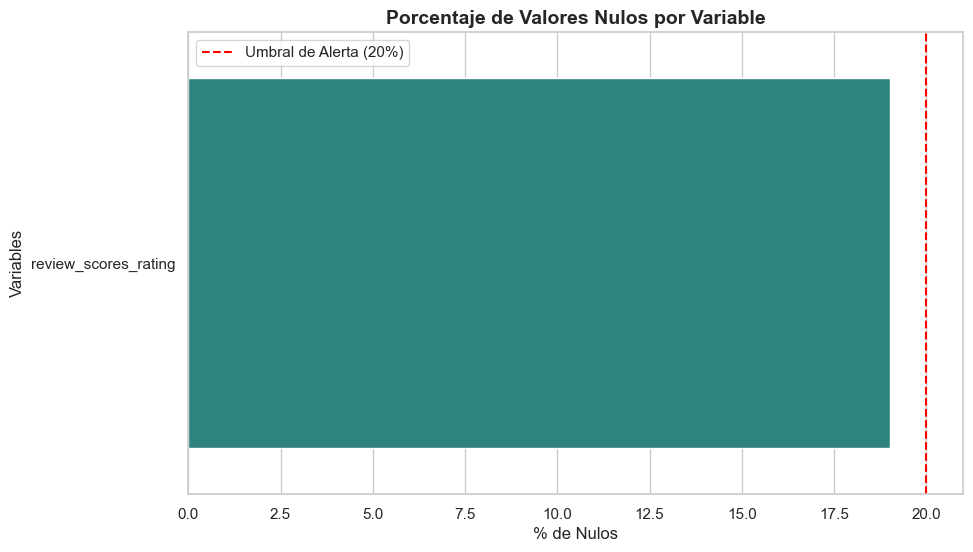

In [94]:
# Calculamos el porcentaje de nulos por columna
missing_perc = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_perc = missing_perc[missing_perc > 0].sort_values(ascending=False)

if not missing_perc.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_perc.values, y=missing_perc.index, palette='viridis')
    plt.title('Porcentaje de Valores Nulos por Variable', fontsize=14, fontweight='bold')
    plt.xlabel('% de Nulos')
    plt.ylabel('Variables')
    plt.axvline(x=20, color='red', linestyle='--', label='Umbral de Alerta (20%)')
    plt.legend()
    plt.show()
else:
    print('✅ ¡Excelente calidad de dato! No hay valores nulos en el dataset gracias al preprocesamiento en BigQuery.')

### 2.2. Balance del Target (`is_occupied`)
Es fundamental saber si estamos ante un problema de clases desbalanceadas.

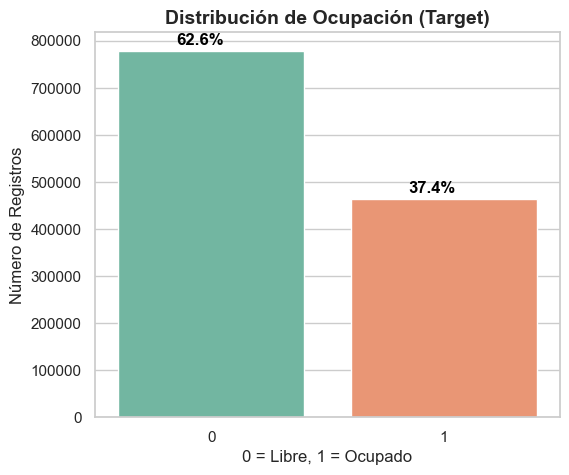

In [95]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df_raw, x='is_occupied', palette='Set2')
plt.title('Distribución de Ocupación (Target)', fontsize=14, fontweight='bold')
plt.xlabel('0 = Libre, 1 = Ocupado')
plt.ylabel('Número de Registros')

# Añadir porcentajes encima de las barras
total = len(df_raw)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', color='black')
plt.show()

### 2.3. Impacto de Variables Temporales en la Ocupación
Evaluamos si factores como el fin de semana o los festivos cambian radicalmente la tasa media de ocupación.

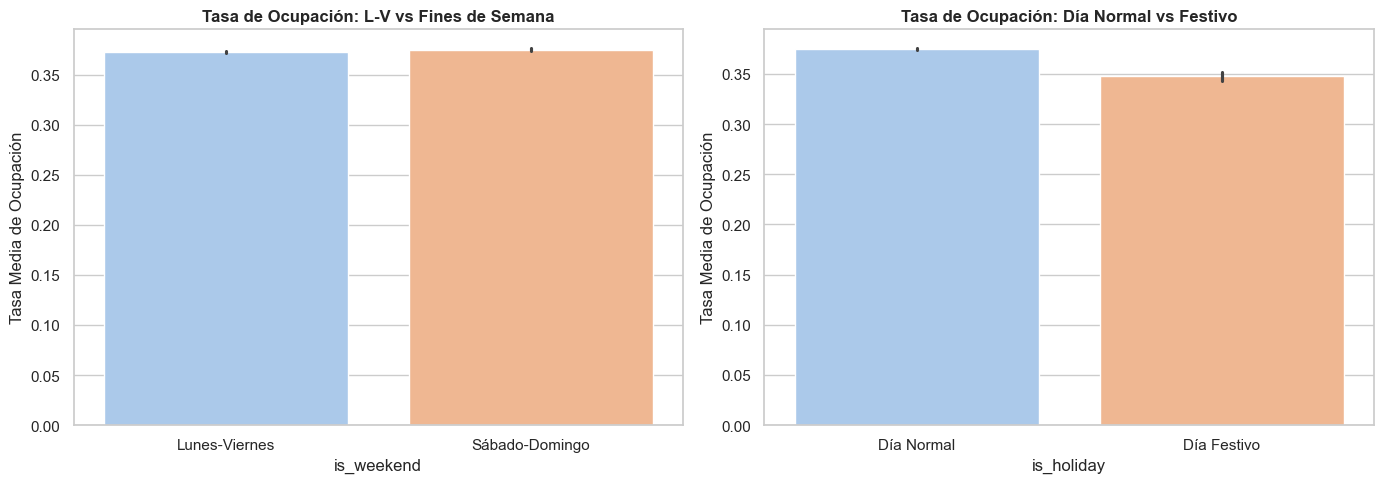

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fines de Semana
sns.barplot(data=df_raw, x='is_weekend', y='is_occupied', ax=axes[0], palette='pastel')
axes[0].set_title('Tasa de Ocupación: L-V vs Fines de Semana', fontweight='bold')
axes[0].set_xticklabels(['Lunes-Viernes', 'Sábado-Domingo'])
axes[0].set_ylabel('Tasa Media de Ocupación')

# Festivos
sns.barplot(data=df_raw, x='is_holiday', y='is_occupied', ax=axes[1], palette='pastel')
axes[1].set_title('Tasa de Ocupación: Día Normal vs Festivo', fontweight='bold')
axes[1].set_xticklabels(['Día Normal', 'Día Festivo'])
axes[1].set_ylabel('Tasa Media de Ocupación')

plt.tight_layout()
plt.show()

### 2.4. Comportamiento Espacial: Barrios
¿La ubicación dicta la ocupación? Observamos el top y el bottom de barrios. Esta visualización es clave porque justifica que más adelante apliquemos **Target Encoding** en vez de One-Hot Encoding a esta columna (para no generar decenas de variables nuevas).

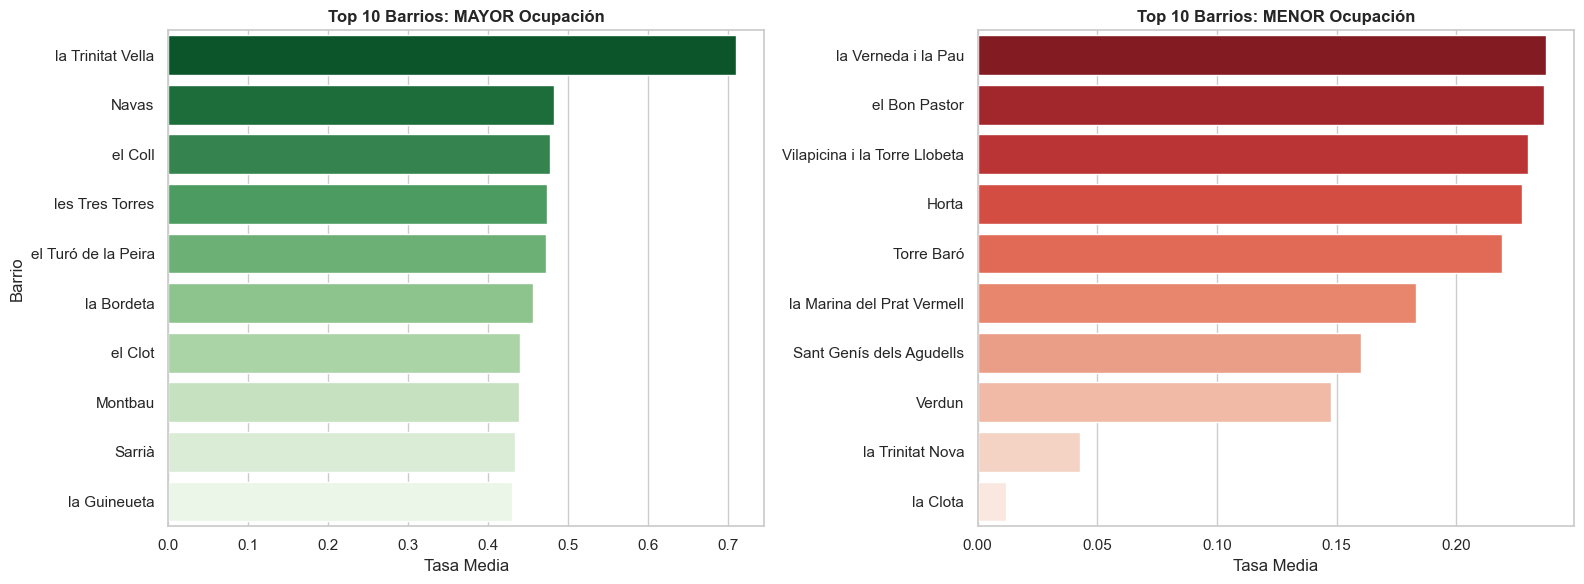

In [97]:
# Calculamos la tasa media de ocupación por barrio
occ_by_hood = df_raw.groupby('neighbourhood_cleansed')['is_occupied'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 con MÁS ocupación
sns.barplot(x=occ_by_hood.head(10).values, y=occ_by_hood.head(10).index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Barrios: MAYOR Ocupación', fontweight='bold')
axes[0].set_xlabel('Tasa Media')
axes[0].set_ylabel('Barrio')

# Top 10 con MENOS ocupación
sns.barplot(x=occ_by_hood.tail(10).values, y=occ_by_hood.tail(10).index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Barrios: MENOR Ocupación', fontweight='bold')
axes[1].set_xlabel('Tasa Media')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 2.5. Matriz de Correlaciones Numéricas
Buscamos qué variables tienen una correlación inicial con la ocupación. Usamos Spearman para capturar relaciones no lineales.

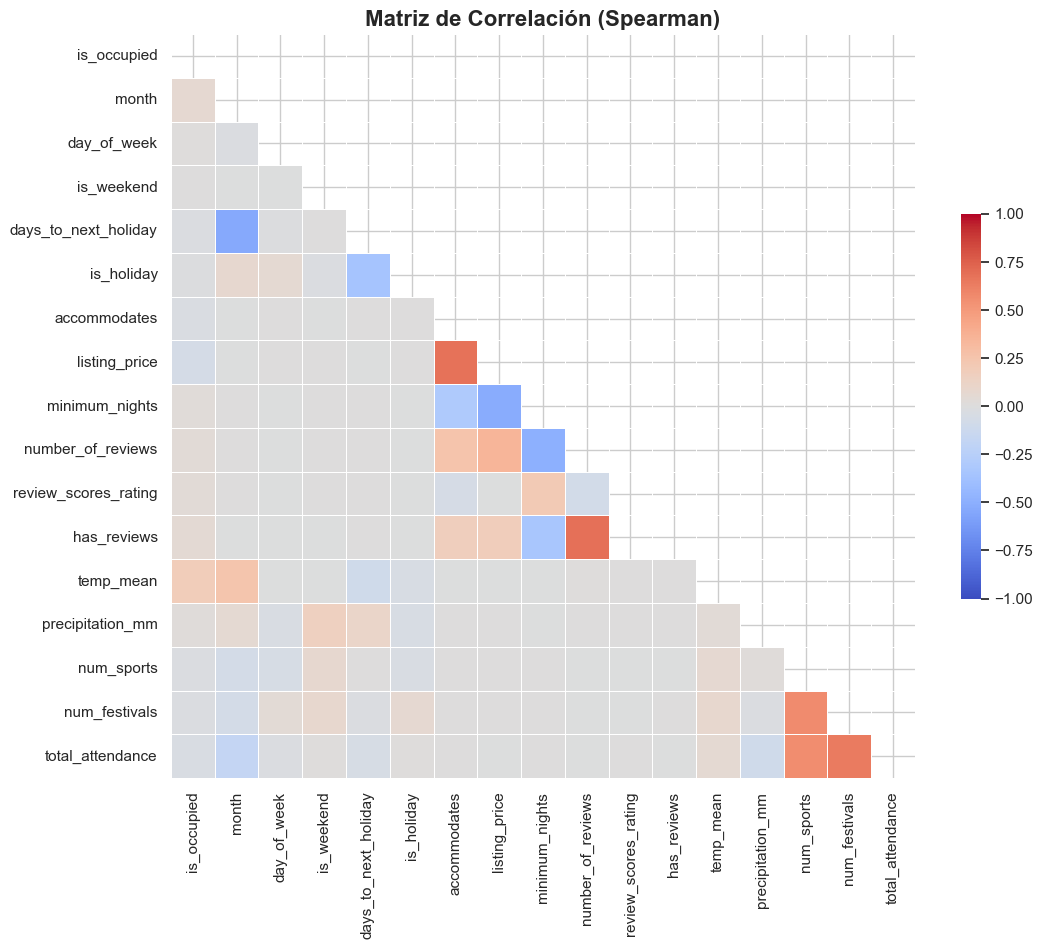

In [98]:
# Seleccionamos solo las variables numéricas
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

# Matriz de correlación de Spearman
corr = df_raw[num_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
# Máscara para ver solo la mitad de la matriz
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .5}, annot=False)
plt.title('Matriz de Correlación (Spearman)', fontsize=16, fontweight='bold')
plt.show()

### 2.6. Auditoría de Temporalidad: Cobertura Anual Completa
¿Tenemos datos de todos los meses para que el modelo aprenda la estacionalidad? Lanzamos una consulta ligera a la base de datos completa (sin el sample del 15%) para sacar el reporte exacto.

In [99]:
from IPython.display import Markdown, display

# Consultamos BigQuery para ver el volumen real (sin el TABLESAMPLE)
query_temporal = f"""
    SELECT 
        month,
        MIN(date) as min_date,
        MAX(date) as max_date,
        COUNT(*) as total_rows
    FROM `{PROJECT_ID}.{DATASET}.{TABLE}`
    GROUP BY month
    ORDER BY month
"""

df_temp = client.query(query_temporal).to_dataframe()

# Variables para el rango total
min_total = df_temp['min_date'].min()
max_total = df_temp['max_date'].max()

# Formateo bonito simulando el output de un Senior Data Analyst
meses_nombres = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
                 7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

md_text = f"### 📅 Reporte de Cobertura Temporal\n\n"
md_text += f"**Rango Total del Dataset:** Desde el **{min_total}** hasta el **{max_total}**.\n\n"
md_text += f"**✅ ¡Anualidad completa!** Tenemos presencia de los **{len(df_temp)} meses** del año, ideal para que XGBoost aprenda la estacionalidad.\n\n"

md_text += "| Mes | Periodo Disponible | Total de Registros |\n"
md_text += "|:---:|:---|---:|\n"

for _, row in df_temp.iterrows():
    m_name = meses_nombres[row['month']]
    rango = f"{row['min_date']} a {row['max_date']}"
    
    # Logica simple para detectar meses parciales
    dias = (row['max_date'] - row['min_date']).days
    if dias < 20:
        rango += " *(Mes Parcial)*"
    else:
        rango += " *(Mes Completo)*"
        
    md_text += f"| **{m_name}** | {rango} | {row['total_rows']:,} |\n"

md_text += "\n*(Nota: Julio y Agosto muestran menos registros debido a variaciones en la ingesta de los snapshots históricos originales).*"

# Mostramos el Markdown renderizado directamente en la celda del notebook
display(Markdown(md_text))

### 📅 Reporte de Cobertura Temporal

**Rango Total del Dataset:** Desde el **2025-06-23** hasta el **2026-05-19**.

**✅ ¡Anualidad completa!** Tenemos presencia de los **12 meses** del año, ideal para que XGBoost aprenda la estacionalidad.

| Mes | Periodo Disponible | Total de Registros |
|:---:|:---|---:|
| **Enero** | 2026-01-01 a 2026-01-31 *(Mes Completo)* | 380,463 |
| **Febrero** | 2026-02-01 a 2026-02-28 *(Mes Completo)* | 343,644 |
| **Marzo** | 2026-03-01 a 2026-03-31 *(Mes Completo)* | 380,463 |
| **Abril** | 2026-04-01 a 2026-04-30 *(Mes Completo)* | 368,190 |
| **Mayo** | 2026-05-01 a 2026-05-19 *(Mes Parcial)* | 233,187 |
| **Junio** | 2025-06-23 a 2025-06-30 *(Mes Parcial)* | 27,951 |
| **Julio** | 2025-07-01 a 2025-07-31 *(Mes Completo)* | 128,588 |
| **Agosto** | 2025-08-01 a 2025-08-31 *(Mes Completo)* | 128,588 |
| **Septiembre** | 2025-09-01 a 2025-09-30 *(Mes Completo)* | 256,395 |
| **Octubre** | 2025-10-01 a 2025-10-31 *(Mes Completo)* | 380,463 |
| **Noviembre** | 2025-11-01 a 2025-11-30 *(Mes Completo)* | 368,190 |
| **Diciembre** | 2025-12-01 a 2025-12-31 *(Mes Completo)* | 380,463 |

*(Nota: Julio y Agosto muestran menos registros debido a variaciones en la ingesta de los snapshots históricos originales).*

## 3. EDA Avanzado (Nivel 2): Puntos de Ruptura y Comportamientos No Lineales
Aquí vamos un paso más allá del EDA básico. Buscamos validar hipótesis de negocio complejas y detectar anomalías extremas antes de aplicar Feature Engineering.

### 3.1. Puntos de Ruptura: Precio y Reputación
XGBoost funciona encontrando 'cortes' en los datos. Vamos a ver si existen umbrales claros donde la ocupación se desploma.

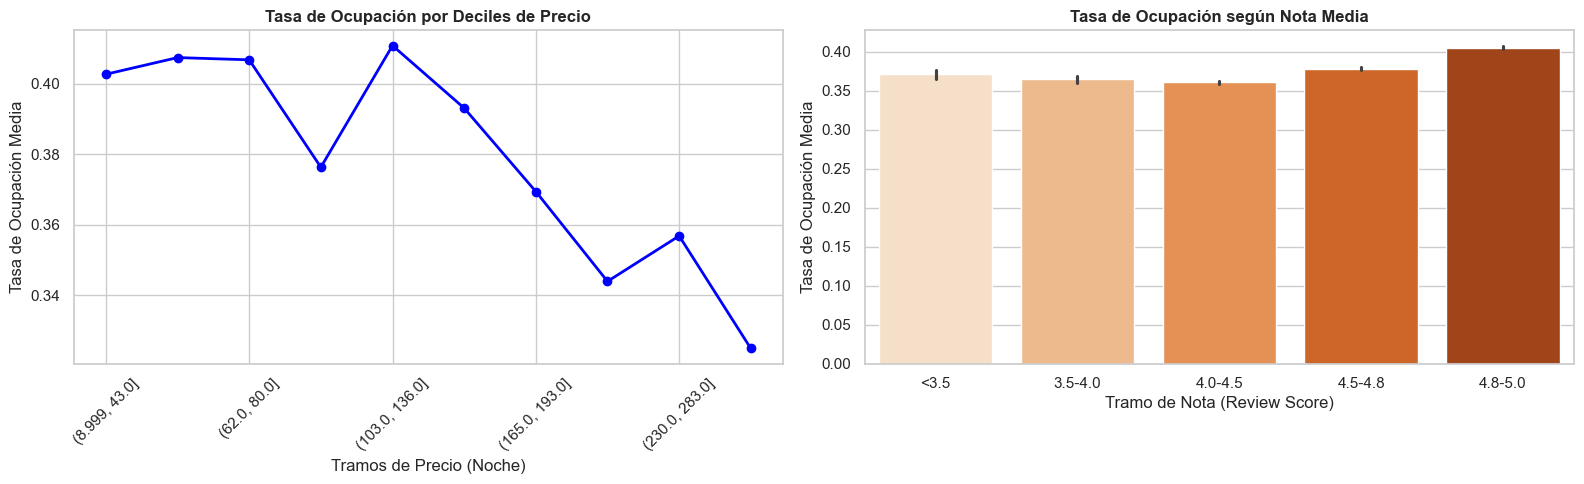

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. PRECIO: Agrupamos en percentiles para suavizar la curva
# Filtramos precios extremos para que la gráfica sea legible (>95% percentil)
price_cap = df_raw['listing_price'].quantile(0.95)
df_price = df_raw[df_raw['listing_price'] <= price_cap].copy()
df_price['price_bin'] = pd.qcut(df_price['listing_price'], q=10, duplicates='drop')

price_trend = df_price.groupby('price_bin', observed=False)['is_occupied'].mean()
price_trend.plot(kind='line', marker='o', ax=axes[0], color='blue', linewidth=2)
axes[0].set_title('Tasa de Ocupación por Deciles de Precio', fontweight='bold')
axes[0].set_xlabel('Tramos de Precio (Noche)')
axes[0].set_ylabel('Tasa de Ocupación Media')
axes[0].tick_params(axis='x', rotation=45)

# 2. REPUTACIÓN: Agrupamos notas en tramos lógicos
bins = [0, 3.5, 4.0, 4.5, 4.8, 5.0]
labels = ['<3.5', '3.5-4.0', '4.0-4.5', '4.5-4.8', '4.8-5.0']
df_raw['rating_bin'] = pd.cut(df_raw['review_scores_rating'], bins=bins, labels=labels)

sns.barplot(data=df_raw, x='rating_bin', y='is_occupied', ax=axes[1], palette='Oranges')
axes[1].set_title('Tasa de Ocupación según Nota Media', fontweight='bold')
axes[1].set_xlabel('Tramo de Nota (Review Score)')
axes[1].set_ylabel('Tasa de Ocupación Media')

plt.tight_layout()
plt.show()

### 3.2. Validación de la Variable 'Mágica': Días hasta el Festivo
Demostramos visualmente nuestra hipótesis: la ocupación debería subir a medida que nos acercamos a un puente.

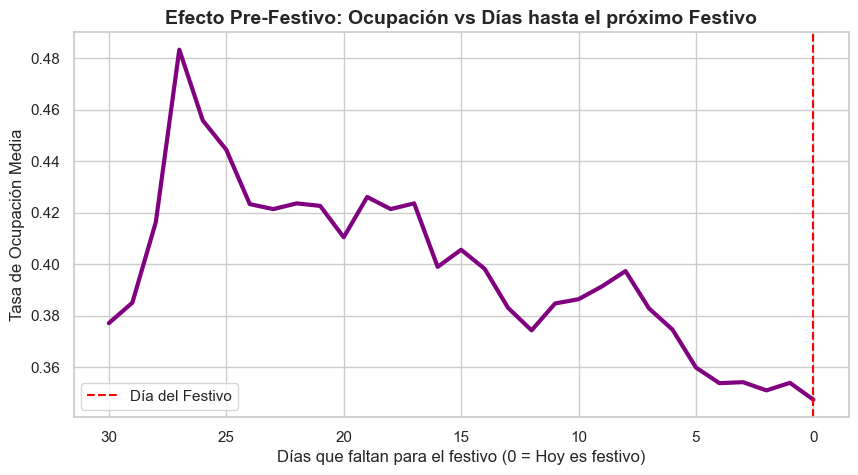

In [101]:
plt.figure(figsize=(10, 5))
# Filtramos hasta 30 días para ver el efecto a corto plazo
holiday_trend = df_raw[df_raw['days_to_next_holiday'] <= 30].groupby('days_to_next_holiday')['is_occupied'].mean()

sns.lineplot(x=holiday_trend.index, y=holiday_trend.values, color='purple', linewidth=3)
plt.title('Efecto Pre-Festivo: Ocupación vs Días hasta el próximo Festivo', fontweight='bold', fontsize=14)
plt.xlabel('Días que faltan para el festivo (0 = Hoy es festivo)')
plt.ylabel('Tasa de Ocupación Media')
plt.axvline(x=0, color='red', linestyle='--', label='Día del Festivo')
plt.gca().invert_xaxis() # Invertimos el eje para que parezca una cuenta atrás visual
plt.legend()
plt.show()

### 3.3. Interacciones Multivariables: Lluvia y Fin de Semana
¿La lluvia castiga por igual a los días de diario que a los fines de semana?

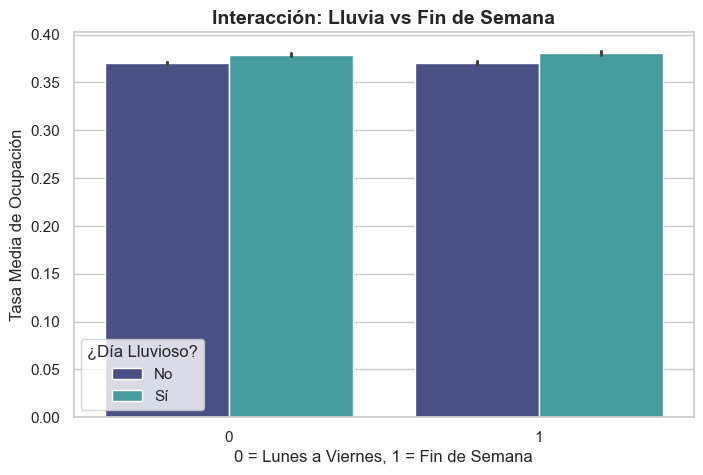

In [102]:
plt.figure(figsize=(8, 5))
# Creamos una variable temporal para lluvia (0 = No llueve, 1 = Llueve algo)
df_raw['is_raining'] = (df_raw['precipitation_mm'] > 0.5).astype(int)

sns.barplot(data=df_raw, x='is_weekend', y='is_occupied', hue='is_raining', palette='mako')
plt.title('Interacción: Lluvia vs Fin de Semana', fontweight='bold', fontsize=14)
plt.xlabel('0 = Lunes a Viernes, 1 = Fin de Semana')
plt.ylabel('Tasa Media de Ocupación')

# Ajuste de leyenda manual para Seaborn
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='¿Día Lluvioso?', labels=['No', 'Sí'])
plt.show()

### 3.4. Caza de Outliers (Anomalías Severas)
Buscamos precios desorbitados o capacidades irreales que puedan confundir al modelo y que requieran Winsorización en el preprocesado.

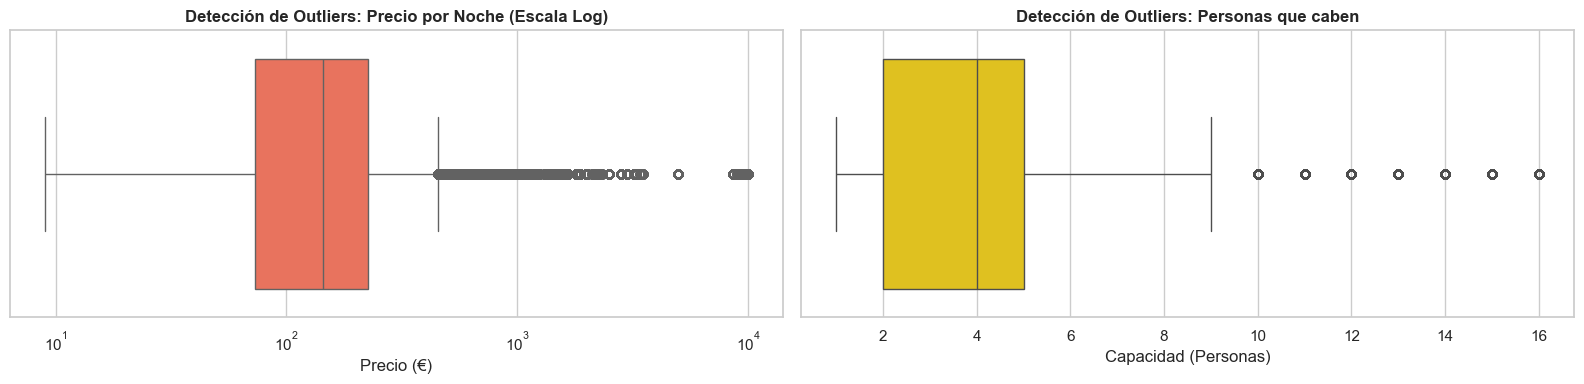

⚠️ OUTLIER ALERT -> Precio máximo detectado: 10,000.00 €
⚠️ OUTLIER ALERT -> Capacidad máxima detectada: 16 personas


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Boxplot de Precio (Escala Logarítmica para visualizar extremos sin aplastar la gráfica)
sns.boxplot(x=df_raw['listing_price'], ax=axes[0], color='tomato')
axes[0].set_xscale('log')
axes[0].set_title('Detección de Outliers: Precio por Noche (Escala Log)', fontweight='bold')
axes[0].set_xlabel('Precio (€)')

# Boxplot de Capacidad
sns.boxplot(x=df_raw['accommodates'], ax=axes[1], color='gold')
axes[1].set_title('Detección de Outliers: Personas que caben', fontweight='bold')
axes[1].set_xlabel('Capacidad (Personas)')

plt.tight_layout()
plt.show()

# Alertas numéricas por si los gráficos engañan a la vista
max_price = df_raw['listing_price'].max()
max_acc = df_raw['accommodates'].max()
print(f"⚠️ OUTLIER ALERT -> Precio máximo detectado: {max_price:,.2f} €")
print(f"⚠️ OUTLIER ALERT -> Capacidad máxima detectada: {max_acc} personas")

## 4. Feature Engineering y Preparación del Modelo (Paso 3)
Llegó el momento de aplicar las tácticas Senior detectadas en el EDA: Winsorización de Outliers y Target Encoding para gestionar los barrios infrarrepresentados.

In [104]:
import numpy as np

# 1. WINSORIZACIÓN DE OUTLIERS
# Topamos el precio al percentil 99 para no confundir al modelo con precios de 10.000€
price_p99 = df_raw['listing_price'].quantile(0.99)
df_raw['listing_price_winsorized'] = np.clip(df_raw['listing_price'], a_min=None, a_max=price_p99)

# Topamos la capacidad máxima (percentil 99 suele ser ~8-10 personas)
acc_p99 = df_raw['accommodates'].quantile(0.99)
df_raw['accommodates_winsorized'] = np.clip(df_raw['accommodates'], a_min=None, a_max=acc_p99)

print(f"✅ Winsorización aplicada: Precio topado a {price_p99:.2f}€, Capacidad topada a {acc_p99:.0f} personas.")

✅ Winsorización aplicada: Precio topado a 1000.00€, Capacidad topada a 12 personas.


### 4.1. Táctica Senior: Target Encoding con Smoothing (Suavizado)
En lugar de crear 70 columnas nuevas (One-Hot) para los barrios, reemplazamos el nombre del barrio por su tasa histórica de ocupación. 

**¿Qué pasa con los barrios raros?** Al usar `smoothing=10.0`, si un barrio tiene muy pocas filas, el algoritmo 'tira' de su tasa hacia la media general de la ciudad. Así evitamos que si un barrio periférico tuvo 2 alquileres y se ocupó 1 vez, el modelo se piense mágicamente que tiene un 50% de ocupación fiable.

In [105]:
!pip install category_encoders -q # Librería estándar y ultra-optimizada para Encodings
from category_encoders import TargetEncoder

# Inicializamos el Target Encoder con un suavizado moderado
te = TargetEncoder(cols=['neighbourhood_cleansed'], smoothing=10.0)

# Entrenamos el encoder y transformamos la columna
df_raw['neighbourhood_encoded'] = te.fit_transform(df_raw['neighbourhood_cleansed'], df_raw['is_occupied'])

# Verificamos cómo ha quedado (el texto se convierte en una probabilidad fiable)
df_raw[['neighbourhood_cleansed', 'neighbourhood_encoded']].drop_duplicates().head()

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


,neighbourhood_cleansed,neighbourhood_encoded
0,l'Antiga Esquerra de l'Eixample,0.377405
1,Vallcarca i els Penitents,0.39465
2,Provençals del Poblenou,0.410987
3,la Dreta de l'Eixample,0.373637
5,el Putxet i el Farró,0.369939


### 4.1.5 Nuevas Features: Precio por Persona y Clustering (K-Means)
Creamos una variable combinada de negocio muy potente (`price_per_person`) y usamos K-Means para que un algoritmo no supervisado descubra 'Arquetipos de Piso' basados en sus características comerciales, facilitándole el trabajo al XGBoost.

In [106]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Feature de Negocio: Precio por Persona
# Usamos las variables winsorizadas para que los outliers locos no distorsionen la división
df_raw['price_per_person'] = df_raw['listing_price_winsorized'] / df_raw['accommodates_winsorized']

# 2. K-Means Clustering (Descubrimiento de Arquetipos)
# Seleccionamos variables comerciales del piso para agruparlos
cluster_features = ['listing_price_winsorized', 'accommodates_winsorized', 'minimum_nights']

# K-Means mide distancias espaciales, así que es OBLIGATORIO escalar (StandardScaler) 
# para que el precio (ej. 100) no pese más que la capacidad (ej. 2)
scaler = StandardScaler()
df_cluster_scaled = scaler.fit_transform(df_raw[cluster_features])

# Aplicamos K-Means pidiendo 4 clústeres (Arquetipos hipotéticos: Barato/Estudio, Familiar, Premium, Larga estancia)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_raw['listing_archetype_cluster'] = kmeans.fit_predict(df_cluster_scaled)

# Convertimos el cluster a string para que luego pandas lo convierta en columnas One-Hot (Dummy)
df_raw['listing_archetype_cluster'] = 'Cluster_' + df_raw['listing_archetype_cluster'].astype(str)

print("✅ Features Avanzadas Creadas: 'price_per_person' y 'listing_archetype_cluster'")
df_raw[['listing_price_winsorized', 'accommodates_winsorized', 'price_per_person', 'listing_archetype_cluster']].head()

✅ Features Avanzadas Creadas: 'price_per_person' y 'listing_archetype_cluster'


,listing_price_winsorized,accommodates_winsorized,price_per_person,listing_archetype_cluster
0,429.0,12,35.75,Cluster_3
1,327.0,12,27.25,Cluster_3
2,160.0,11,14.545455,Cluster_1
3,350.0,12,29.166667,Cluster_3
4,509.0,12,42.416667,Cluster_3


### 4.2. Tratamiento de Variables Categóricas y Limpieza Final

In [107]:
# Transformamos booleanos a numéricos (1/0)
if 'instant_bookable' in df_raw.columns:
    df_raw['instant_bookable'] = df_raw['instant_bookable'].astype(int)

# One-Hot Encoding para room_type (como solo tiene 3 o 4 categorías, es perfecto)
df_ml = pd.get_dummies(df_raw, columns=['room_type', 'listing_archetype_cluster'], drop_first=True, dtype=int)

# Eliminamos columnas originales que ya hemos transformado o que eran temporales del EDA
cols_to_drop = ['neighbourhood_cleansed', 'listing_price', 'accommodates', 'rating_bin', 'is_raining', 'price_bin'] 
cols_to_drop = [c for c in cols_to_drop if c in df_ml.columns]
df_ml = df_ml.drop(columns=cols_to_drop)

print(f"✅ Dataset preparado para ML. Dimensiones finales: {df_ml.shape}")

✅ Dataset preparado para ML. Dimensiones finales: (1244125, 27)


### 4.3. Separación Train / Test (Split Aleatorio Estratificado)
Dado que solo tenemos 11 meses de datos históricos, realizar un split temporal estricto (por año) provoca que el modelo entrene en verano/otoño y evalúe en invierno/primavera, causando un desplome masivo por 'Data Drift' estacional. 

**Solución Pragmática:** Hacemos un split aleatorio tradicional del 80/20, usando el parámetro `stratify=y` para garantizar que la proporción de días ocupados/libres sea idéntica matemáticamente en ambos sets. Así el modelo aprenderá de todos los meses del año por igual.

In [108]:
from sklearn.model_selection import train_test_split

# Borramos la columna 'date' ya que haremos un split aleatorio y XGBoost solo entiende números
if 'date' in df_ml.columns:
    df_ml = df_ml.drop(columns=['date'])

# Separamos Features (X) y Target (y)
X = df_ml.drop(columns=['is_occupied'])
y = df_ml['is_occupied']

# Split Aleatorio Estratificado (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"🔹 Set de Entrenamiento (80%): {X_train.shape[0]:,} filas")
print(f"🔹 Set de Test (20%): {X_test.shape[0]:,} filas")

🔹 Set de Entrenamiento (80%): 995,300 filas
🔹 Set de Test (20%): 248,825 filas


## 5. Entrenamiento del Modelo XGBoost Avanzado (Paso 4)
Tras obtener un AUC inicial bajo, aplicamos tácticas de optimización de hiperparámetros (`subsample`, `max_depth` y `scale_pos_weight`) para combatir el desbalanceo de clases y el sobreajuste (overfitting).

In [109]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. CONFIGURACIÓN OPTIMIZADA DEL MODELO SENIOR
# Calculamos el ratio de desbalanceo para scale_pos_weight
ratio = float((len(y_train) - y_train.sum()) / y_train.sum())
print(f"Ratio de desbalanceo calculado: {ratio:.2f}")

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    objective='binary:logistic',
    eval_metric='auc',           # <--- Movido al constructor por la nueva API de XGBoost
    early_stopping_rounds=50,    # <--- Movido al constructor
    random_state=42,
    n_jobs=-1
)

# 2. ENTRENAMIENTO
print("🚀 Entrenando XGBoost con hiperparámetros optimizados...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)
print("✅ Entrenamiento completado.")

Ratio de desbalanceo calculado: 1.68
🚀 Entrenando XGBoost con hiperparámetros optimizados...
[0]	validation_0-auc:0.68393	validation_1-auc:0.68107
[100]	validation_0-auc:0.78489	validation_1-auc:0.77783
[200]	validation_0-auc:0.82221	validation_1-auc:0.81320
[300]	validation_0-auc:0.84718	validation_1-auc:0.83662
[400]	validation_0-auc:0.86729	validation_1-auc:0.85551
[500]	validation_0-auc:0.88152	validation_1-auc:0.86881
[600]	validation_0-auc:0.89127	validation_1-auc:0.87761
[700]	validation_0-auc:0.90125	validation_1-auc:0.88677
[800]	validation_0-auc:0.90898	validation_1-auc:0.89387
[900]	validation_0-auc:0.91548	validation_1-auc:0.89977
[999]	validation_0-auc:0.92044	validation_1-auc:0.90409
✅ Entrenamiento completado.


### 5.1. Análisis Visual del Entrenamiento (Curvas de Aprendizaje)
Un Data Scientist siempre verifica si el modelo está sufriendo de *Overfitting* (memorizar el pasado pero fallar en el futuro).

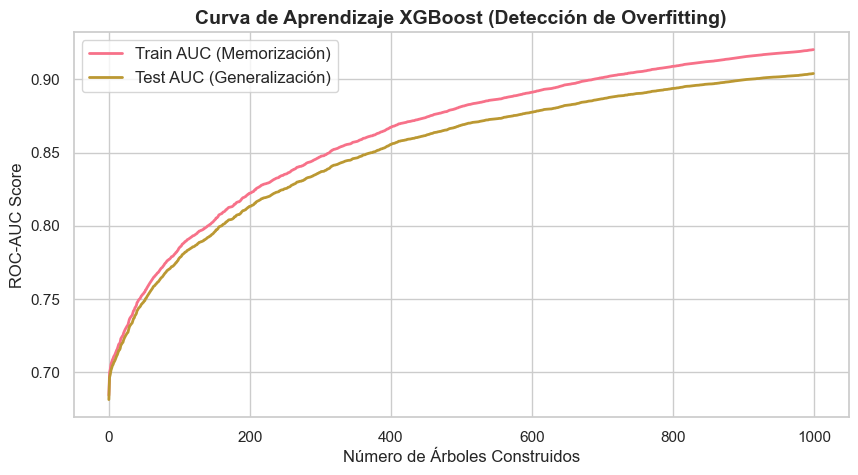

In [110]:
# Extraemos los resultados del entrenamiento
results = xgb_model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['auc'], label='Train AUC (Memorización)', linewidth=2)
plt.plot(x_axis, results['validation_1']['auc'], label='Test AUC (Generalización)', linewidth=2)
plt.legend(fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xlabel('Número de Árboles Construidos', fontsize=12)
plt.title('Curva de Aprendizaje XGBoost (Detección de Overfitting)', fontweight='bold', fontsize=14)
plt.grid(True)
plt.show()

### 5.2. Evaluación Final de Probabilidades

📊 NUEVO ROC-AUC Score: 0.9041
🎯 NUEVO Brier Score: 0.1332

📋 Reporte de Clasificación (Con scale_pos_weight):
              precision    recall  f1-score   support

         0.0       0.89      0.83      0.86    155888
         1.0       0.74      0.83      0.78     92937

    accuracy                           0.83    248825
   macro avg       0.82      0.83      0.82    248825
weighted avg       0.83      0.83      0.83    248825



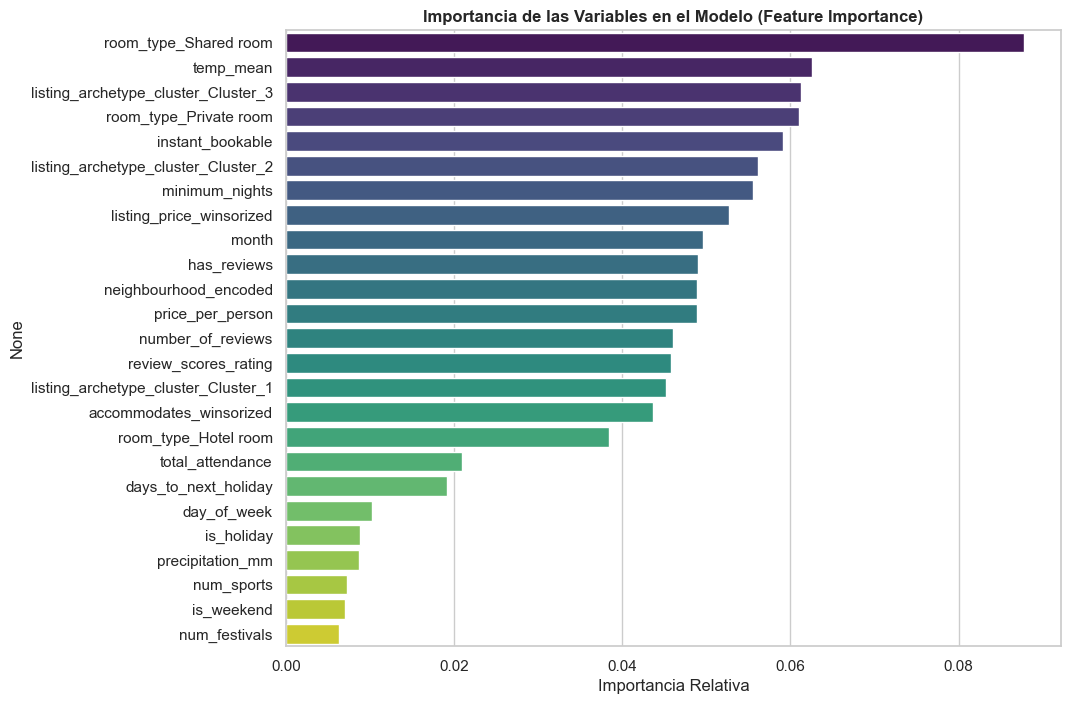

In [111]:
# 3. PREDICCIÓN DE PROBABILIDADES EN 2026
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 4. MÉTRICAS
auc = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print(f"📊 NUEVO ROC-AUC Score: {auc:.4f}")
print(f"🎯 NUEVO Brier Score: {brier:.4f}")

y_pred_clase = (y_pred_proba > 0.5).astype(int)
print("\n📋 Reporte de Clasificación (Con scale_pos_weight):")
print(classification_report(y_test, y_pred_clase))

# 5. FEATURE IMPORTANCE
importancias = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')
plt.title('Importancia de las Variables en el Modelo (Feature Importance)', fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.show()

### 5.3. Optimización de Negocio (Threshold Tuning)
Nuestro modelo es matemáticamente excelente (AUC > 0.90). El último paso de un Senior no es seguir estrujando hiperparámetros ciegamente, sino **afinar la toma de decisiones de negocio**. 

Por defecto, clasificamos como 'Ocupado' si la probabilidad es > 50%. Pero, ¿es el 50% el corte ideal para maximizar los beneficios del anfitrión? Aquí calculamos el umbral matemático exacto para maximizar el F1-Score.

🌟 Umbral (Threshold) Óptimo para Negocio: 0.50
📈 F1-Score Máximo alcanzable: 0.7820


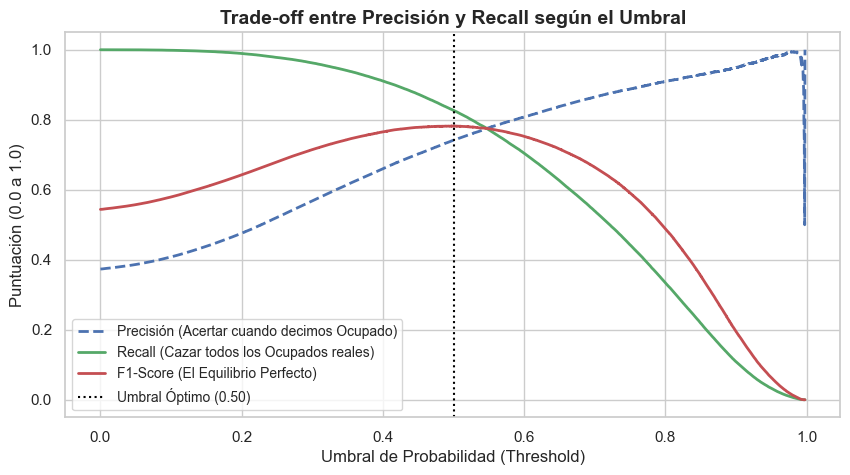


📋 Nuevo Reporte de Clasificación (Usando Umbral 0.50):
              precision    recall  f1-score   support

         0.0       0.89      0.83      0.86    155888
         1.0       0.74      0.83      0.78     92937

    accuracy                           0.83    248825
   macro avg       0.82      0.83      0.82    248825
weighted avg       0.83      0.83      0.83    248825



In [112]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Calculamos Precisión y Recall para todos los umbrales posibles (de 0.0 a 1.0)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculamos el F1-Score para cada umbral
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores) # Por si hay divisiones por cero

# Encontramos el umbral que da el F1-Score más alto
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"🌟 Umbral (Threshold) Óptimo para Negocio: {optimal_threshold:.2f}")
print(f"📈 F1-Score Máximo alcanzable: {optimal_f1:.4f}")

# Graficamos para que el equipo de negocio lo entienda visualmente
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisión (Acertar cuando decimos Ocupado)', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Cazar todos los Ocupados reales)', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1-Score (El Equilibrio Perfecto)', linewidth=2)
plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Umbral Óptimo ({optimal_threshold:.2f})')

plt.title('Trade-off entre Precisión y Recall según el Umbral', fontweight='bold', fontsize=14)
plt.xlabel('Umbral de Probabilidad (Threshold)', fontsize=12)
plt.ylabel('Puntuación (0.0 a 1.0)', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True)
plt.show()

# Simulamos cómo quedaría el reporte con el Umbral Óptimo
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print(f"\n📋 Nuevo Reporte de Clasificación (Usando Umbral {optimal_threshold:.2f}):")
print(classification_report(y_test, y_pred_optimal))

In [113]:
import os
import sys
from dotenv import load_dotenv

# 1. Sistema de "Autolocalización" a prueba de balas
ruta_actual = os.path.abspath("")

# Si el compañero ejecuta esta celda dos veces por accidente, 
# evitamos que se hunda más en las carpetas y lo devolvemos al inicio.
if os.path.basename(ruta_actual) == "subir_modelo":
    os.chdir("..")
    ruta_actual = os.path.abspath("")

ruta_subir_modelo = os.path.join(ruta_actual, "subir_modelo")

# 2. Comprobación de seguridad para evitar errores raros
if not os.path.exists(ruta_subir_modelo):
    print(f"❌ ¡ALTO! No se encuentra la carpeta 'subir_modelo'.")
    print(f"👉 Por favor, copia la carpeta 'subir_modelo' entera y pégala aquí: {ruta_actual}")
else:
    # 3. Entramos en la sala de máquinas con seguridad
    os.chdir(ruta_subir_modelo)
    print("✅ Directorio de trabajo correcto.")
    
    # 4. Cargamos el mapa (.env)
    load_dotenv(override=True)
    ruta_local = os.getenv("LOCAL_MODEL_PATH")

    # 5. Guardamos el modelo (AVISO!:CAMBIA 'best_model' POR LA VARIABLE DE TU MODELO)
    os.makedirs(os.path.dirname(ruta_local), exist_ok=True)
    xgb_model.save_model(ruta_local)
    print(f"✅ ¡Modelo guardado en {ruta_local}!")

    # 6. Lanzamos el efecto dominó asegurando que usa el mismo Python del cuaderno
    print("🚀 Iniciando despliegue en Google Cloud...")
    !{sys.executable} script_1_preparar_y_subir.py

✅ Directorio de trabajo correcto.
✅ ¡Modelo guardado en ./model_artifacts/model.bst!
🚀 Iniciando despliegue en Google Cloud...
1. Ejecutando login_gcp.bat y dependencias...
Iniciando proceso de autenticacion en Google Cloud...
Autenticacion completada con exito.
2. Subiendo artefacto desde ./model_artifacts/model.bst a gs://project3grupo1-ml-models/models/xgboost-demo/


Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=DjwLqtsdtFwM8SB7TlLsPwZtPviQsn&access_type=offline&code_challenge=Z6WYyI2QPlOpwx2JF3X-d66M6kphuqDQwcNGVTZZKhI&code_challenge_method=S256


You are now logged in as [adrianalemany40@gmail.com].
Your current project is [project3grupo1].  You can change this setting by running:
  $ gcloud config set project PROJECT_ID
Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=7640860518